In [38]:
%load_ext autoreload
%autoreload 2
# %matplotlib ipympl

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [1]:
import mesa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.animation import FuncAnimation
from abm.model import SocialGPModel
from abm.rewards import make_mexican_hat_reward, make_parent_and_children_correlated_dog
from abm.utils import plot_reward_grid, plot_most_common_choice_trajectory, animate_heatmap_trajectory, sample_parameters_from_csv
from abm.batch_analysis import (
    run_condition_batches,
    run_sampled_batches,
    run_distributed_batches,
    summarize_condition_timeseries,
    summarize_mean_reward_last_steps,
    plot_condition_comparison,
    summarize_batch_metrics,
    plot_metric_suite_by_lambda,
 )

sns.set_theme(style="whitegrid")

# Single agent simulations
This notebook shows simulations done to establish the behavior of single agents in Mexican hat environments, sampling parameters from empirical distributions for each iteration

## 1. Naito 2022

### 2.a Simulate average behavior

In [15]:
grid_size   = 33
lambda_true = 4.5

# Original environment lambda parameters (from previous experiments)
naito_lambda_source = 1.5  
giron_lambda_source = 0.43

# Define reward parameters for the correlated dog environment
reward_params = {
    'length_scale': lambda_true,
    'sigma_outer': lambda_true,
    'sigma_inner': lambda_true/2.0,
}

### Sample parameters from Naito 2022 dataset

Run batch simulations where parameters (length_scale, tau, beta) are sampled from the empirical distributions in naito2022.csv. Each run samples a new parameter set from the dataset.

In [ ]:
# Base parameters - parameters not in param_columns will use these fixed values
base_params = {
    "n": 1,
    "grid_size": grid_size,
    "alpha": 0,  # Fixed value (not in dataset)
    "reward_env_type": 'mexican_hat_2_valleys',
    "reward_env_params": [reward_params],
    "agent_reporters_to_collect": ["reward", "global_max", "local_max", "no_max", "cumulative_reward"],
}

# Mapping from model parameter names to CSV column names
param_columns = {
    'length_scale': 'lambda_0',
    'tau': 'tau_0',
    'beta': 'beta_0',
}

# Scaling: Naito parameters were fit for lambda_true=1.5, scale to our lambda_true=4.5
# Formula: scaled_value = sample * target_lambda / source_lambda
param_scaling = {
    'length_scale': (naito_lambda_source, lambda_true),
}

# Run batch with sampled parameters
n_runs    = 50  # Number of runs (will sample n_runs parameter sets from CSV)
max_steps = 30
rng       = np.random.default_rng(42)

sampled_df = run_sampled_batches(
    model_cls=SocialGPModel,
    base_parameters=base_params,
    csv_path='datasets/naito2022.csv',
    param_columns=param_columns,
    param_scaling=param_scaling,
    n_runs=n_runs,
    max_steps=max_steps,
    data_collection_period=1,
    display_progress=True,
    condition_name='naito_sampled',
    rng=rng,
)

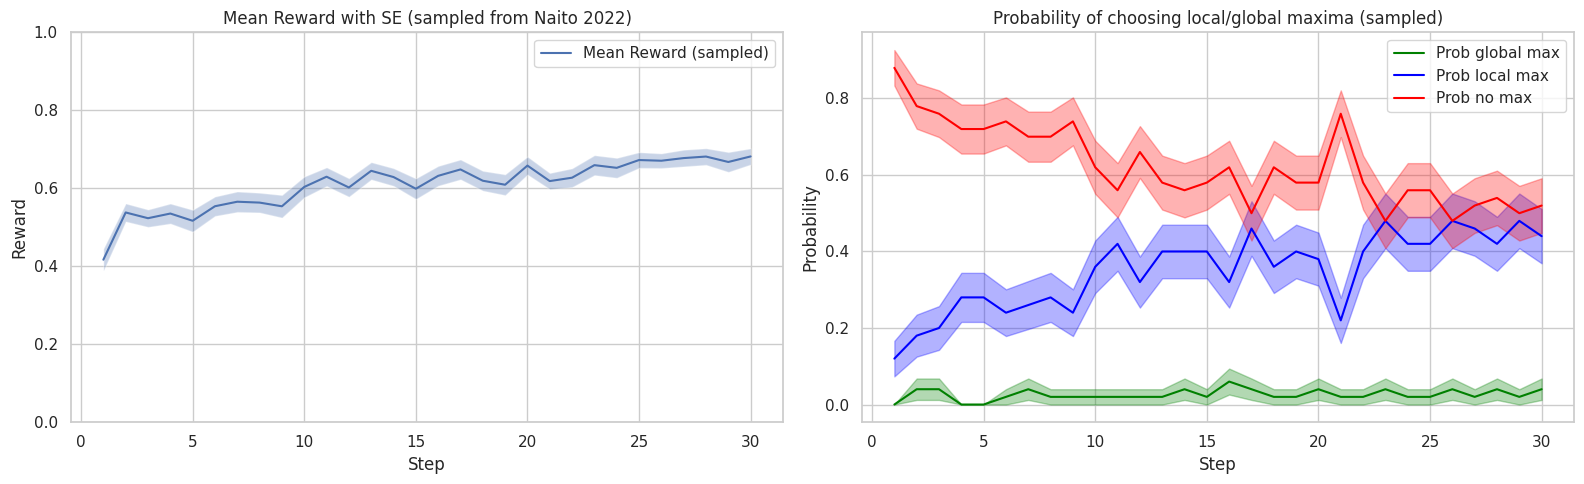

In [ ]:
# Visualize results from sampled parameters
df_grouped = sampled_df.groupby('Step').agg({
    'reward': ['mean', 'std'],
    'global_max': ['mean', 'std'],
    'local_max': ['mean', 'std'],
    'no_max': ['mean', 'std']
}).reset_index()

# Plot mean reward and probabilities in adjacent subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: mean reward with std
reward_mean = df_grouped['reward']['mean']
reward_SE = df_grouped['reward']['std'] / np.sqrt(n_runs) 
axes[0].plot(df_grouped['Step'], reward_mean, label='Mean Reward (sampled)')
axes[0].fill_between(df_grouped['Step'], reward_mean - reward_SE, reward_mean + reward_SE, alpha=0.3)
axes[0].set_title('Mean Reward with SE (sampled from Naito 2022)')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Reward')
axes[0].set_ylim(0, 1)
axes[0].legend()

# Right: probabilities
global_max_mean = df_grouped['global_max']['mean']
global_max_SE = df_grouped['global_max']['std'] / np.sqrt(n_runs)
local_max_mean = df_grouped['local_max']['mean']
local_max_SE = df_grouped['local_max']['std'] / np.sqrt(n_runs)
axes[1].plot(df_grouped['Step'], global_max_mean, label='Prob global max', color='green')
axes[1].fill_between(df_grouped['Step'], global_max_mean - global_max_SE, global_max_mean + global_max_SE, alpha=0.3, color='green')
axes[1].plot(df_grouped['Step'], local_max_mean, label='Prob local max', color='blue')
axes[1].fill_between(df_grouped['Step'], local_max_mean - local_max_SE, local_max_mean + local_max_SE, alpha=0.3, color='blue')
not_any_max_mean = df_grouped['no_max']['mean']
not_any_max_SE = df_grouped['no_max']['std'] / np.sqrt(n_runs)
axes[1].plot(df_grouped['Step'], not_any_max_mean, label='Prob no max', color='red')
axes[1].fill_between(df_grouped['Step'], not_any_max_mean - not_any_max_SE, not_any_max_mean + not_any_max_SE, alpha=0.3, color='red')
axes[1].set_title('Probability of choosing local/global maxima (sampled)')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('Probability')
axes[1].legend()

plt.tight_layout()
plt.show()

## 2. Sample from parametrized distributions 
as in Witt 2024

In [167]:
# Original environment lambda parameters (from previous experiments)
naito_lambda_source = 1.5  
giron_lambda_source = 4.0
witt_lambda_source  = 2.0

# Define reward parameters for the Mexican Hat GP environment
grid_size   = 13
lambda_true = 2.0
reward_params = {
    'length_scale': lambda_true,
    'sigma_outer': lambda_true,
    'sigma_inner': lambda_true/2.0,
    'local_global_max_ratio': 1.3
}

# Set up distributions to sample parameters from, and scale them to match our environment's lambda_true
param_distributions = {
    'length_scale': {'distribution': 'lognormal', 'mu': -0.75, 'sigma': 0.5},
    'beta': {'distribution': 'lognormal', 'mu': -0.75, 'sigma': 0.5},
    'tau': {'distribution': 'lognormal', 'mu': -4.5, 'sigma': 0.75}
}
param_scaling = {
    'length_scale': (witt_lambda_source, lambda_true),
}

# Other parameters for running the model
base_params = {
    "n": 1,
    "grid_size": grid_size,
    "alpha": 0,  # Fixed value 
    "reward_env_type": 'mexican_hat_gp',
    "reward_env_params": [reward_params],
    "agent_reporters_to_collect": ["reward", "global_max", "local_max", "no_max", "cumulative_reward"],
}

# Run batch
n_runs    = 50
max_steps = 30
rng       = np.random.default_rng(42)
results   = run_distributed_batches(
    model_cls=SocialGPModel,
    base_parameters=base_params,
    param_distributions=param_distributions,
    param_scaling=param_scaling,
    n_runs=n_runs,
    max_steps=max_steps,
    data_collection_period=1,
    display_progress=True,
    condition_name='Witt sigma outer',
    rng=rng,
)

Completed run 1/50
Completed run 2/50
Completed run 3/50
Completed run 4/50
Completed run 5/50
Completed run 6/50
Completed run 7/50
Completed run 8/50
Completed run 9/50
Completed run 10/50
Completed run 11/50
Completed run 12/50
Completed run 13/50
Completed run 14/50
Completed run 15/50
Completed run 16/50
Completed run 17/50
Completed run 18/50
Completed run 19/50
Completed run 20/50
Completed run 21/50
Completed run 22/50
Completed run 23/50
Completed run 24/50
Completed run 25/50
Completed run 26/50
Completed run 27/50
Completed run 28/50
Completed run 29/50
Completed run 30/50
Completed run 31/50
Completed run 32/50
Completed run 33/50
Completed run 34/50
Completed run 35/50
Completed run 36/50
Completed run 37/50
Completed run 38/50
Completed run 39/50
Completed run 40/50
Completed run 41/50
Completed run 42/50
Completed run 43/50
Completed run 44/50
Completed run 45/50
Completed run 46/50
Completed run 47/50
Completed run 48/50
Completed run 49/50
Completed run 50/50


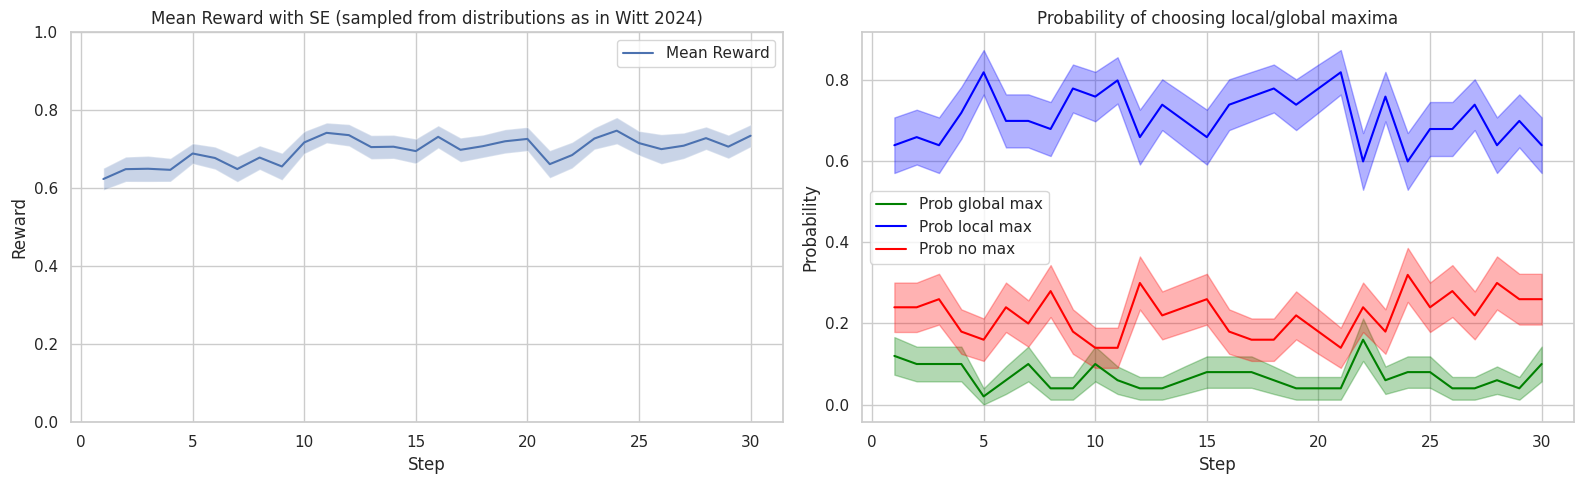

In [168]:
# Visualize results from sampled parameters
df_grouped = results.groupby('Step').agg({
    'reward': ['mean', 'std'],
    'global_max': ['mean', 'std'],
    'local_max': ['mean', 'std'],
    'no_max': ['mean', 'std']
}).reset_index()

# Plot mean reward and probabilities in adjacent subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: mean reward with std
reward_mean = df_grouped['reward']['mean']
reward_SE = df_grouped['reward']['std'] / np.sqrt(n_runs) 
axes[0].plot(df_grouped['Step'], reward_mean, label='Mean Reward')
axes[0].fill_between(df_grouped['Step'], reward_mean - reward_SE, reward_mean + reward_SE, alpha=0.3)
axes[0].set_title('Mean Reward with SE (sampled from distributions as in Witt 2024)')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Reward')
axes[0].set_ylim(0, 1)
axes[0].legend()

# Right: probabilities
global_max_mean = df_grouped['global_max']['mean']
global_max_SE = df_grouped['global_max']['std'] / np.sqrt(n_runs)
local_max_mean = df_grouped['local_max']['mean']
local_max_SE = df_grouped['local_max']['std'] / np.sqrt(n_runs)
axes[1].plot(df_grouped['Step'], global_max_mean, label='Prob global max', color='green')
axes[1].fill_between(df_grouped['Step'], global_max_mean - global_max_SE, global_max_mean + global_max_SE, alpha=0.3, color='green')
axes[1].plot(df_grouped['Step'], local_max_mean, label='Prob local max', color='blue')
axes[1].fill_between(df_grouped['Step'], local_max_mean - local_max_SE, local_max_mean + local_max_SE, alpha=0.3, color='blue')
not_any_max_mean = df_grouped['no_max']['mean']
not_any_max_SE = df_grouped['no_max']['std'] / np.sqrt(n_runs)
axes[1].plot(df_grouped['Step'], not_any_max_mean, label='Prob no max', color='red')
axes[1].fill_between(df_grouped['Step'], not_any_max_mean - not_any_max_SE, not_any_max_mean + not_any_max_SE, alpha=0.3, color='red')
axes[1].set_title('Probability of choosing local/global maxima')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('Probability')
axes[1].legend()

plt.tight_layout()
plt.show()

# 2. Estimate $t_{MH}, t_{GP}$

In [39]:
from abm.utils import sample_parameters_from_distributions

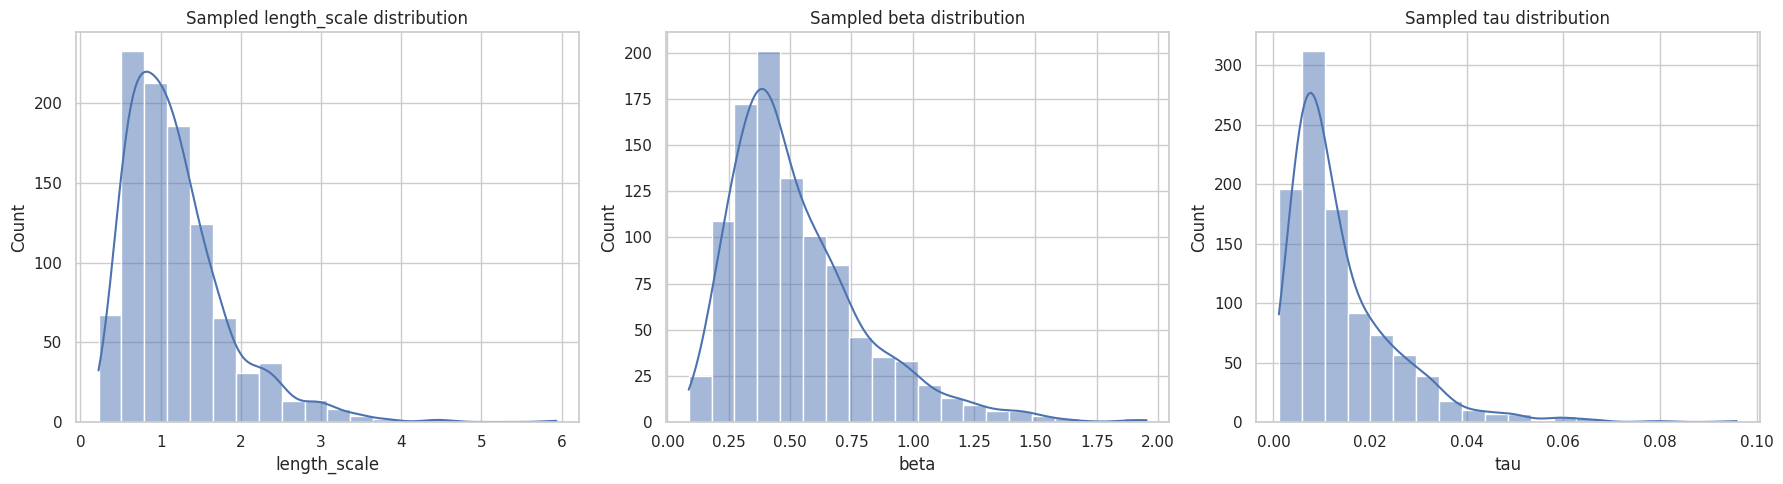

In [62]:
# Original environment lambda parameters (from previous experiments)
naito_lambda_source = 1.5  
giron_lambda_source = 4.0
witt_lambda_source  = 2.0

param_distributions = {
    'length_scale': {'distribution': 'lognormal', 'mu': -0.75, 'sigma': 0.5},
    'beta': {'distribution': 'lognormal', 'mu': -0.75, 'sigma': 0.5},
    'tau': {'distribution': 'lognormal', 'mu': -4.5, 'sigma': 0.75}
}
param_scaling = {
    'length_scale': (witt_lambda_source, lambda_true),
}
params = sample_parameters_from_distributions(
    param_distributions=param_distributions,
    param_scaling=param_scaling,
    n_samples=1000,
)

# transform list of dicts to DataFrame for easier plotting
params_df = pd.DataFrame(params)

# plot histogram of each sampled parameter from dataframe
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, param in enumerate(['length_scale', 'beta', 'tau']):
    sns.histplot(params_df[param], bins=20, kde=True, ax=axes[i])
    axes[i].set_title(f'Sampled {param} distribution')
plt.tight_layout()
plt.show()

In [169]:
import os
import glob
import pandas as pd
import numpy as np

def process_parameter_sweep_folder(folder_path):
    """
    Process all CSV files in a folder containing parameter sweep results.
    
    Creates a streamlined table with one row per (iteration, beta, length_scale, tau, alpha) combination,
    adding t_global_max (first Step where global_max=1) and t_local_max (first Step where local_max=1).
    
    Parameters:
    -----------
    folder_path : str
        Path to the folder containing CSV files
        
    Returns:
    --------
    pd.DataFrame
        Streamlined dataframe with columns: iteration, Step, beta, length_scale, tau, alpha, 
        global_max, mean_cumulative_reward, t_global_max, t_local_max
    """
    # Find all CSV files in the folder
    csv_files = glob.glob(os.path.join(folder_path, "*.csv"))
    
    if not csv_files:
        raise ValueError(f"No CSV files found in {folder_path}")
    
    print(f"Found {len(csv_files)} CSV files")
    
    # Read and concatenate all CSV files
    dfs = []
    for csv_file in csv_files:
        df = pd.read_csv(csv_file)
        dfs.append(df)
    
    combined_df = pd.concat(dfs, ignore_index=True)
    print(f"Total rows: {len(combined_df)}")
    
    # Define the key columns for grouping
    key_cols = ['iteration', 'beta', 'length_scale', 'tau', 'alpha']
    
    # Ensure columns exist
    required_cols = key_cols + ['Step', 'global_max', 'local_max', 'mean_cumulative_reward']
    missing_cols = [col for col in required_cols if col not in combined_df.columns]
    if missing_cols:
        raise ValueError(f"Missing columns: {missing_cols}")
    
    # Sort by key columns and Step to ensure proper ordering
    combined_df = combined_df.sort_values(key_cols + ['Step'])
    
    # Find first Step where global_max = 1 for each group
    global_max_first = combined_df[combined_df['global_max'] == 1].groupby(key_cols)['Step'].min().reset_index()
    global_max_first.columns = key_cols + ['t_global_max']
    
    # Find first Step where local_max = 1 for each group
    local_max_first = combined_df[combined_df['local_max'] == 1].groupby(key_cols)['Step'].min().reset_index()
    local_max_first.columns = key_cols + ['t_local_max']
    
    # Get the last row for each group (contains final values)
    last_rows = combined_df.groupby(key_cols).last().reset_index()
    
    # Select only the columns we want to keep
    cols_to_keep = key_cols + ['Step', 'global_max', 'local_max', 'no_max', 'mean_cumulative_reward']
    result_df = last_rows[cols_to_keep].copy()
    
    # Merge t_global_max and t_local_max
    result_df = result_df.merge(global_max_first, on=key_cols, how='left')
    result_df = result_df.merge(local_max_first, on=key_cols, how='left')
    
    # Convert to appropriate types
    result_df['t_global_max'] = result_df['t_global_max'].astype('Int64')  # Nullable integer
    result_df['t_local_max'] = result_df['t_local_max'].astype('Int64')  # Nullable integer
    
    print(f"Result shape: {result_df.shape}")
    print(f"Columns: {result_df.columns.tolist()}")
    
    return result_df

# Example usage:
result = process_parameter_sweep_folder('/scratch/parra/lambda_sweep_oft_R3/')
result.head()

Found 50 CSV files
Total rows: 1500000
Result shape: (5000, 12)
Columns: ['iteration', 'beta', 'length_scale', 'tau', 'alpha', 'Step', 'global_max', 'local_max', 'no_max', 'mean_cumulative_reward', 't_global_max', 't_local_max']


Found 50 CSV files
Total rows: 1500000
Result shape: (5000, 12)
Columns: ['iteration', 'beta', 'length_scale', 'tau', 'alpha', 'Step', 'global_max', 'local_max', 'no_max', 'mean_cumulative_reward', 't_global_max', 't_local_max']


,iteration,beta,length_scale,tau,alpha,Step,global_max,local_max,no_max,mean_cumulative_reward,t_global_max,t_local_max
0,0,0.3,0.500000,0.03,0.0,300.0,0,0,1,276.151046,<NA>,1
1,0,0.3,0.610142,0.03,0.0,300.0,1,0,0,666.466752,75,<NA>
2,0,0.3,0.744548,0.03,0.0,300.0,0,0,1,284.305748,<NA>,15
3,0,0.3,0.908560,0.03,0.0,300.0,0,0,1,283.903326,<NA>,2
4,0,0.3,1.108702,0.03,0.0,300.0,1,0,0,670.586760,7,<NA>


In [171]:
# Step 1: Group by length_scale and beta, compute average t_ values (NA -> 700)
result_filled = result.copy()
result_filled['t_global_max'] = result_filled['t_global_max'].fillna(700)
result_filled['t_local_max'] = result_filled['t_local_max'].fillna(700)

# Group by length_scale and beta, compute mean
grouped_avg = result_filled.groupby(['length_scale', 'beta']).agg({
    't_global_max': 'mean',
    't_local_max': 'mean'
}).reset_index()

print("Average t values grouped by length_scale and beta:")
print(grouped_avg.head(10))
print(f"\nShape: {grouped_avg.shape}")

# Step 2: Compute expected values using lognormal distribution
# prob(parameter) = lognormal(mu=-0.75, sigma=0.5)
from scipy import stats

# Get unique length_scale and beta values from grouped_avg
length_scales = grouped_avg['length_scale'].unique()
betas = grouped_avg['beta'].unique()

# Create meshgrid for all combinations
length_scale_grid, beta_grid = np.meshgrid(length_scales, betas)
length_scale_vals = length_scale_grid.ravel()
beta_vals = beta_grid.ravel()

# Compute probabilities for each parameter combination
# Using lognormal distribution with mu=-0.75, sigma=0.5
lognorm = stats.lognorm(s=0.5, scale=np.exp(-0.75))

# Probability for each length_scale and beta
prob_length_scale = lognorm.pdf(length_scale_vals)
prob_beta = lognorm.pdf(beta_vals)

# Joint probability (assuming independence)
joint_prob = prob_length_scale * prob_beta
joint_prob = joint_prob / joint_prob.sum()  # Normalize to sum to 1

# Get t values for each (length_scale, beta) combination
t_global_max_vals = []
t_local_max_vals = []

for ls, b in zip(length_scale_vals, beta_vals):
    row = grouped_avg[(grouped_avg['length_scale'] == ls) & (grouped_avg['beta'] == b)]
    if len(row) > 0:
        t_global_max_vals.append(row['t_global_max'].values[0])
        t_local_max_vals.append(row['t_local_max'].values[0])
    else:
        t_global_max_vals.append(np.nan)
        t_local_max_vals.append(np.nan)

t_global_max_vals = np.array(t_global_max_vals)
t_local_max_vals = np.array(t_local_max_vals)

# Compute expected values: sum of prob(param) * t_value(param)
expected_t_global_max = np.nansum(joint_prob * t_global_max_vals)
expected_t_local_max = np.nansum(joint_prob * t_local_max_vals)

print(f"\nExpected t_global_max (weighted by lognormal): {expected_t_global_max:.2f}")
print(f"Expected t_local_max (weighted by lognormal): {expected_t_local_max:.2f}")

Average t values grouped by length_scale and beta:
   length_scale  beta  t_global_max  t_local_max
0      0.500000   0.3        298.46        84.53
1      0.500000   0.4        106.68        88.95
2      0.500000   0.5         103.8        76.16
3      0.500000   0.6         68.28        95.96
4      0.500000   0.7        101.99        69.46
5      0.610142   0.3        382.71         94.2
6      0.610142   0.4        233.61        55.52
7      0.610142   0.5        203.94        68.92
8      0.610142   0.6        178.83        68.88
9      0.610142   0.7        200.88        83.04

Shape: (50, 4)

Expected t_global_max (weighted by lognormal): 243.51
Expected t_local_max (weighted by lognormal): 77.35


(<Figure size 1000x800 with 2 Axes>,
 <Axes: title={'center': 'Exploration Advantage Heatmap\n(t_gp=5, t_dog=51)'}, xlabel='Time Budget (T)', ylabel='DoG Reward Multiplier (R)'>)

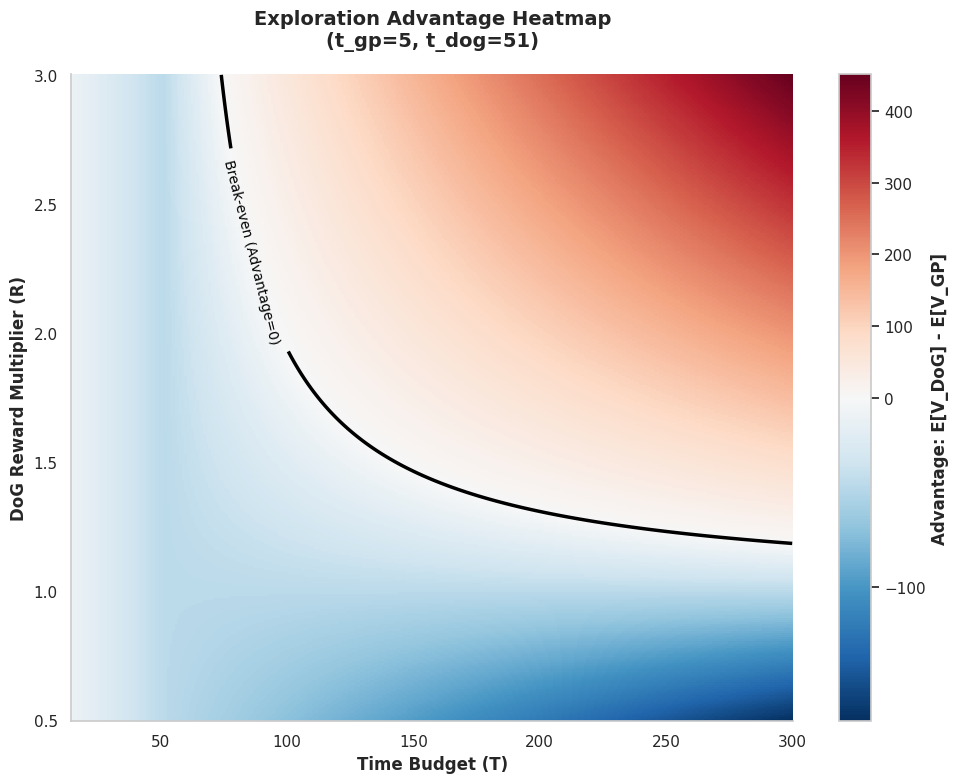

In [87]:
from abm.visualization_optimal_dog import plot_foraging_advantage_heatmap
plot_foraging_advantage_heatmap(
    t_gp=5, #ound(expected_t_local_max), 
    t_dog=51, #round(expected_t_global_max), 
    max_T=300, 
    max_R=3.0
)

Found 50 CSV files
Total rows: 1500000
Averaged DataFrame shape: (15000, 10)
Unique Steps: 300

Averaged DataFrame sample:
   beta  length_scale   tau  alpha  Step  global_max  local_max  no_max  \
0   0.3           0.5  0.03    0.0   1.0        0.06       0.15    0.79   
1   0.3           0.5  0.03    0.0   2.0        0.04       0.18    0.78   
2   0.3           0.5  0.03    0.0   3.0        0.03       0.16    0.81   
3   0.3           0.5  0.03    0.0   4.0        0.05       0.25    0.70   
4   0.3           0.5  0.03    0.0   5.0        0.06       0.16    0.78   
5   0.3           0.5  0.03    0.0   6.0        0.06       0.20    0.74   
6   0.3           0.5  0.03    0.0   7.0        0.04       0.17    0.79   
7   0.3           0.5  0.03    0.0   8.0        0.05       0.19    0.76   
8   0.3           0.5  0.03    0.0   9.0        0.07       0.24    0.69   
9   0.3           0.5  0.03    0.0  10.0        0.06       0.24    0.70   

   mean_cumulative_reward    reward  
0            

Found 50 CSV files
Total rows: 1500000
Averaged DataFrame shape: (15000, 10)
Unique Steps: 300

Averaged DataFrame sample:
   beta  length_scale   tau  alpha  Step  global_max  local_max  no_max  \
0   0.3           0.5  0.03    0.0   1.0        0.06       0.15    0.79   
1   0.3           0.5  0.03    0.0   2.0        0.04       0.18    0.78   
2   0.3           0.5  0.03    0.0   3.0        0.03       0.16    0.81   
3   0.3           0.5  0.03    0.0   4.0        0.05       0.25    0.70   
4   0.3           0.5  0.03    0.0   5.0        0.06       0.16    0.78   
5   0.3           0.5  0.03    0.0   6.0        0.06       0.20    0.74   
6   0.3           0.5  0.03    0.0   7.0        0.04       0.17    0.79   
7   0.3           0.5  0.03    0.0   8.0        0.05       0.19    0.76   
8   0.3           0.5  0.03    0.0   9.0        0.07       0.24    0.69   
9   0.3           0.5  0.03    0.0  10.0        0.06       0.24    0.70   

   mean_cumulative_reward    reward  
0            

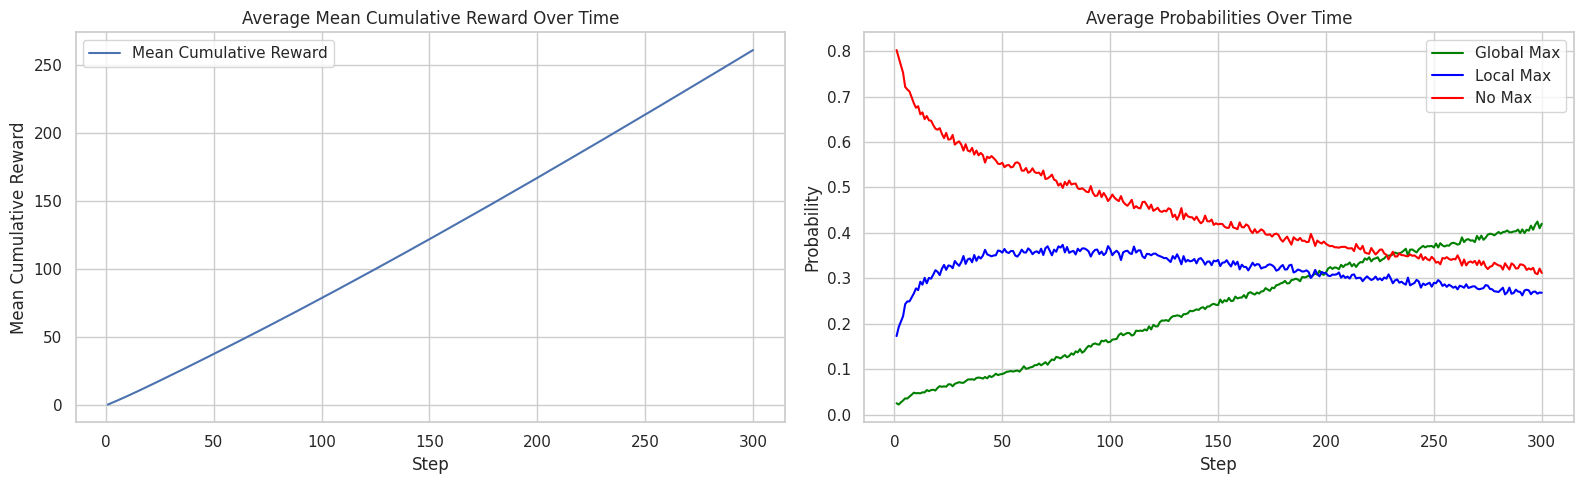

In [172]:
# Step 1: Average across all iterations for same parameter combinations
# Keep all time steps and average across iterations

import os
import glob
import pandas as pd
import numpy as np

def load_and_average_iterations(folder_path):
    """
    Load all CSV files and compute average across iterations for each parameter combination.
    
    Parameters:
    -----------
    folder_path : str
        Path to the folder containing CSV files
        
    Returns:
    --------
    pd.DataFrame
        DataFrame with averaged values across iterations
    """
    # Find all CSV files in the folder
    csv_files = glob.glob(os.path.join(folder_path, "*.csv"))
    
    if not csv_files:
        raise ValueError(f"No CSV files found in {folder_path}")
    
    print(f"Found {len(csv_files)} CSV files")
    
    # Read and concatenate all CSV files
    dfs = []
    for csv_file in csv_files:
        df = pd.read_csv(csv_file)
        dfs.append(df)
    
    combined_df = pd.concat(dfs, ignore_index=True)
    print(f"Total rows: {len(combined_df)}")
    
    # Define the key columns for grouping (parameter combinations)
    key_cols = ['beta', 'length_scale', 'tau', 'alpha']
    
    # Columns to average across iterations
    avg_cols = ['global_max', 'local_max', 'no_max', 'mean_cumulative_reward', 'reward']
    
    # Group by key_cols + Step and compute mean
    grouped = combined_df.groupby(key_cols + ['Step'])[avg_cols].mean().reset_index()
    
    print(f"Averaged DataFrame shape: {grouped.shape}")
    print(f"Unique Steps: {grouped['Step'].nunique()}")
    
    return grouped

# Load and average
averaged_df = load_and_average_iterations('/scratch/parra/lambda_sweep_oft_plot/')
print("\nAveraged DataFrame sample:")
print(averaged_df.head(10))

# Step 2: Calculate average mean_cumulative_reward across all parameter combinations for each time step
# Group by Step and compute mean across all parameter combinations

avg_by_step = averaged_df.groupby('Step').agg({
    'global_max': 'mean',
    'local_max': 'mean',
    'no_max': 'mean',
    'mean_cumulative_reward': 'mean',
    'reward': 'mean'
}).reset_index()

# Sort by Step to ensure proper ordering
avg_by_step = avg_by_step.sort_values('Step').reset_index(drop=True)

print("\n\nAverage across all parameter combinations by Step:")
print(avg_by_step.head(20))
print(f"\nShape: {avg_by_step.shape}")
print(f"Step range: {avg_by_step['Step'].min()} to {avg_by_step['Step'].max()}")

# Plot the results
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: mean_cumulative_reward over time
axes[0].plot(avg_by_step['Step'], avg_by_step['mean_cumulative_reward'], label='Mean Cumulative Reward')
axes[0].set_title('Average Mean Cumulative Reward Over Time')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Mean Cumulative Reward')
axes[0].legend()

# Right: probabilities over time
axes[1].plot(avg_by_step['Step'], avg_by_step['global_max'], label='Global Max', color='green')
axes[1].plot(avg_by_step['Step'], avg_by_step['local_max'], label='Local Max', color='blue')
axes[1].plot(avg_by_step['Step'], avg_by_step['no_max'], label='No Max', color='red')
axes[1].set_title('Average Probabilities Over Time')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('Probability')
axes[1].legend()

plt.tight_layout()
plt.show()

In [175]:
# Load data from two different folders for different R values
# R=1.2 from lambda_sweep_oft_plot, R=3.0 from lambda_sweep_oft_R3

# Load and average for R=1.2 (original folder)
averaged_df_r12 = load_and_average_iterations('/scratch/parra/lambda_sweep_oft_plot/')
avg_by_step_r12 = averaged_df_r12.groupby('Step').agg({
    'global_max': 'mean',
    'local_max': 'mean',
    'no_max': 'mean',
    'mean_cumulative_reward': 'mean',
    'reward': 'mean'
}).reset_index()
avg_by_step_r12 = avg_by_step_r12.sort_values('Step').reset_index(drop=True)
avg_by_step_r12['R'] = 1.2

print(f"R=1.2 data shape: {avg_by_step_r12.shape}")

# Load and average for R=3.0 (new folder)
averaged_df_r30 = load_and_average_iterations('/scratch/parra/lambda_sweep_oft_R3/')
avg_by_step_r30 = averaged_df_r30.groupby('Step').agg({
    'global_max': 'mean',
    'local_max': 'mean',
    'no_max': 'mean',
    'mean_cumulative_reward': 'mean',
    'reward': 'mean'
}).reset_index()
avg_by_step_r30 = avg_by_step_r30.sort_values('Step').reset_index(drop=True)
avg_by_step_r30['R'] = 3.0

print(f"R=3.0 data shape: {avg_by_step_r30.shape}")

# Combine both datasets
combined_avg = pd.concat([avg_by_step_r12, avg_by_step_r30], ignore_index=True)
print(f"\nCombined data shape: {combined_avg.shape}")
print(combined_avg.head())

Found 50 CSV files
Total rows: 1500000
Averaged DataFrame shape: (15000, 10)
Unique Steps: 300
R=1.2 data shape: (300, 7)
Found 50 CSV files
Total rows: 1500000
Averaged DataFrame shape: (15000, 10)
Unique Steps: 300
R=3.0 data shape: (300, 7)

Combined data shape: (600, 7)
   Step  global_max  local_max  no_max  mean_cumulative_reward    reward    R
0   1.0      0.0250     0.1728  0.8022                0.633929  0.633929  1.2
1   2.0      0.0222     0.1928  0.7850                1.283203  0.649274  1.2
2   3.0      0.0270     0.2044  0.7686                1.943828  0.660625  1.2
3   4.0      0.0310     0.2164  0.7526                2.620127  0.676299  1.2
4   5.0      0.0358     0.2432  0.7210                3.304829  0.684702  1.2


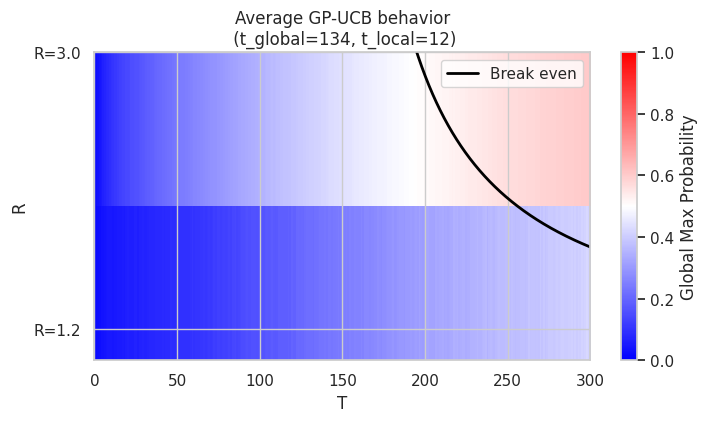

In [181]:
# Create heatmap with two rows: R=1.2 and R=3.0
# Using avg_by_step_r12 and avg_by_step_r30 from previous cell

# Parameters for the R(T) curve
t_global = 134
t_local = 12

# Define R values for the curve (avoid R=1 where denominator is zero)
R_curve = np.linspace(1.15, 3, 1000)  # Start just above 1

# Calculate T from R
T = (R_curve * t_global - t_local) / (R_curve - 1)

plt.figure(figsize=(8, 4))

# Create heatmap data with two rows (R=1.2 and R=3.0)
# Stack the global_max probabilities for both R values
heatmap_data = np.vstack([
    avg_by_step_r12['global_max'].values,
    avg_by_step_r30['global_max'].values
])

# Plot heatmap without interpolation
plt.imshow(heatmap_data,
           aspect='auto',
           extent=[0, 300, 1.0, 3.0],
           origin='lower',
           cmap='bwr',   # blue → red
           interpolation='none',
           vmin=0, vmax=1)    # fix scale from 0 to 1


# Plot the R(T) curve
plt.plot(T, R_curve, color='black', linewidth=2, label='Break even')

plt.xlabel('T')
plt.ylabel('R')
plt.xlim(0, 300)
plt.ylim(1, 3)
plt.yticks([1.2, 3.0], ['R=1.2', 'R=3.0'])
plt.title(f'Average GP-UCB behavior\n (t_global={t_global}, t_local={t_local})')
plt.colorbar(label='Global Max Probability')
plt.legend()
plt.show()